In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statistics
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv('docs/data.csv', sep = ';')
df.head(10)

,COMBUSTIBLE,ESTADO,FECHA_REGISTRO,ANIO_REGISTRO,CLASE,DEPARTAMENTO,CANTIDAD
0,ELECTRICO,ACTIVO,28/09/2015,2015,MOTOCICLETA,Caqueta,1
1,ELECTRICO,ACTIVO,25/10/2021,2021,CAMIONETA,Cundinamarca,1
2,ELECTRICO,ACTIVO,31/10/2019,2019,AUTOMOVIL,Bogota D.C.,1
3,ELECTRICO,ACTIVO,27/08/2021,2021,AUTOMOVIL,Antioquia,1
4,ELECTRICO,ACTIVO,10/06/2020,2020,CAMIONETA,Antioquia,1
5,ELECTRICO,ACTIVO,14/03/2014,2014,MOTOCICLETA,Bogota D.C.,1
6,ELECTRICO,ACTIVO,11/06/2021,2021,MOTOTRICICLO,Cundinamarca,1
7,ELECTRICO,ACTIVO,22/12/2021,2021,CAMIONETA,Bogota D.C.,1
8,ELECTRICO,ACTIVO,23/06/2021,2021,AUTOMOVIL,Antioquia,1
9,ELECTRICO,ACTIVO,14/03/2022,2022,BUS,Bogota D.C.,1


In [6]:
df[df['DEPARTAMENTO'] == 'Bogota D.C.']
df[df['DEPARTAMENTO'] == 'Bogota D.C.']['CLASE'].value_counts()

CLASE
AUTOMOVIL       1365
BUS             1050
MOTOCICLETA      389
CAMIONETA        351
CUADRICICLO      292
MOTOCARRO          6
TRICIMOTO          5
MOTOTRICICLO       3
Name: count, dtype: int64

In [4]:
# Cantidad de filas de nuestro DataSet
print("Cantidad de filas de nuestra BD: ", len(df))

Cantidad de filas de nuestra BD:  7537


In [5]:
# Cantidad de columnas de nuestro DataSet
print("Cantidad de columnas de nuestra BD: ", len(df.columns))

Cantidad de columnas de nuestra BD:  7


In [6]:
# Cantidad de elementos de nuestro DataSet
print("Cantidad de elementos de nuestra BD: ", df.size)

Cantidad de elementos de nuestra BD:  52759


In [7]:
print("Cantidad de datos nullos en nuestra BD: \n", df.isnull)

Cantidad de datos nullos en nuestra BD: 
 <bound method DataFrame.isnull of      COMBUSTIBLE  ESTADO FECHA_REGISTRO  ANIO_REGISTRO        CLASE  \
0      ELECTRICO  ACTIVO     28/09/2015           2015  MOTOCICLETA   
1      ELECTRICO  ACTIVO     25/10/2021           2021    CAMIONETA   
2      ELECTRICO  ACTIVO     31/10/2019           2019    AUTOMOVIL   
3      ELECTRICO  ACTIVO     27/08/2021           2021    AUTOMOVIL   
4      ELECTRICO  ACTIVO     10/06/2020           2020    CAMIONETA   
...          ...     ...            ...            ...          ...   
7532   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7533   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7534   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7535   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7536   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   

      DEPARTAMENTO  CANTIDAD   
0          Caqueta          1  
1     C

In [8]:
# Cantidad de datos NULOS por COLUMNA utilizando isna
print("La cantidad de datos na de la Base de Datos es: \n", df.isna().sum())

La cantidad de datos na de la Base de Datos es: 
 COMBUSTIBLE       0
ESTADO            0
FECHA_REGISTRO    0
ANIO_REGISTRO     0
CLASE             0
DEPARTAMENTO      0
CANTIDAD          0
dtype: int64


In [9]:
# Cantidad de datos por COLUMNA utilizando isna
print("La cantidad de datos na de la Base de Datos es: \n", df.isna().sum().sum())

La cantidad de datos na de la Base de Datos es: 
 0


In [10]:
# Cantidad de datos NULOS
print("La cantidad de filas de la Base de Datos es: \n", df.isnull().sum())

La cantidad de filas de la Base de Datos es: 
 COMBUSTIBLE       0
ESTADO            0
FECHA_REGISTRO    0
ANIO_REGISTRO     0
CLASE             0
DEPARTAMENTO      0
CANTIDAD          0
dtype: int64


In [11]:
# Nombre de la columnas de nuestra BD
print("Los encabezados de nuestra BD son: \n", df.columns)

Los encabezados de nuestra BD son: 
 Index(['COMBUSTIBLE', 'ESTADO', 'FECHA_REGISTRO', 'ANIO_REGISTRO', 'CLASE',
       'DEPARTAMENTO', 'CANTIDAD '],
      dtype='object')


In [12]:
# Mostrar nombre los campos utilizando .keys()
print("Los nombres de los campos son: \n", df.keys)

Los nombres de los campos son: 
 <bound method NDFrame.keys of      COMBUSTIBLE  ESTADO FECHA_REGISTRO  ANIO_REGISTRO        CLASE  \
0      ELECTRICO  ACTIVO     28/09/2015           2015  MOTOCICLETA   
1      ELECTRICO  ACTIVO     25/10/2021           2021    CAMIONETA   
2      ELECTRICO  ACTIVO     31/10/2019           2019    AUTOMOVIL   
3      ELECTRICO  ACTIVO     27/08/2021           2021    AUTOMOVIL   
4      ELECTRICO  ACTIVO     10/06/2020           2020    CAMIONETA   
...          ...     ...            ...            ...          ...   
7532   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7533   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7534   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7535   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   
7536   ELECTRICO  ACTIVO     30/03/2022           2022  CUADRICICLO   

      DEPARTAMENTO  CANTIDAD   
0          Caqueta          1  
1     Cundinamarca  

In [13]:
# Eliminar columnas innecesarios
df.drop(['COMBUSTIBLE', 'ESTADO'], axis = 1, inplace = True)

In [14]:
df.dtypes

FECHA_REGISTRO    object
ANIO_REGISTRO      int64
CLASE             object
DEPARTAMENTO      object
CANTIDAD           int64
dtype: object

In [15]:
# Seleccionar datos numericos
df_numericos = df.select_dtypes(include = ['number'])
# Mostrar los tipos de datos de las columnas para verificar
print(df_numericos.dtypes)

ANIO_REGISTRO    int64
CANTIDAD         int64
dtype: object


In [16]:
# Seleccionar datos no numericos
df_nonumericos = df.select_dtypes(exclude = ['number'])
# Mostrar los tipos de datos de las columnas para verificar
print(df_nonumericos.dtypes)

FECHA_REGISTRO    object
CLASE             object
DEPARTAMENTO      object
dtype: object


In [17]:
# Calcular la media de los registros por año
conteo_por_anio = df.groupby('ANIO_REGISTRO')['CANTIDAD '].count()

print("Conteo de registros por año\n")
print(conteo_por_anio)

Conteo de registros por año

ANIO_REGISTRO
2010      44
2011     108
2012     150
2013     300
2014     250
2015     508
2016     431
2017     248
2018     444
2019     980
2020    1408
2021    1539
2022    1127
Name: CANTIDAD , dtype: int64


In [18]:
# Calcular la media
media = np.mean(conteo_por_anio)
print("La MEDIA de registros por año: ", round(media, 2))

La MEDIA de registros por año:  579.77


In [19]:
mediana = np.median(conteo_por_anio)
print("La MEDIANA de registros por año: ", mediana)

La MEDIANA de registros por año:  431.0


In [20]:
# Sacar varianza con Pandas (Recomendado para DATAFRAME)
varianza_pd = df['ANIO_REGISTRO'].var()
print("La VARIANZA de registros por año: ", varianza_pd)

La VARIANZA de registros por año:  8.70699943266498


In [21]:
# Sacar varianza con Numpy
varianza_np = np.var(df['ANIO_REGISTRO'])
print("La VARIANZA de registros por año: ", varianza_np)

La VARIANZA de registros por año:  8.7058441985622


In [22]:
# Sacar varianza con modulo de Python (statistics)
anio_registro = df['ANIO_REGISTRO']
varianza_stc = statistics.variance(anio_registro)
print("La VARIANZA de registros por año: ", varianza_stc)

La VARIANZA de registros por año:  8.70699943266439


In [23]:
# Desviacion Estandar con Pandas (Recomendado para DATAFRAME)
desviacion_pd = df['ANIO_REGISTRO'].std()
print("La DESVIACION ESTANDAR de registros por año: ", round(desviacion_pd, 2))

La DESVIACION ESTANDAR de registros por año:  2.95


In [24]:
# Desviacion Estandar con Numpy
desviacion_np = np.std(df['ANIO_REGISTRO'])
print("La DESVIACION ESTANDAR de registros por año: ", round(desviacion_np, 2))

La DESVIACION ESTANDAR de registros por año:  2.95


In [25]:
# Desviacion Estandar con modulo de Python (statistics)
desviacion_estandar = df['ANIO_REGISTRO']
desviacion_stc = statistics.stdev(desviacion_estandar)
print("La DESVIACION ESTANDAR de registros por año: ", round(desviacion_stc, 2))

La DESVIACION ESTANDAR de registros por año:  2.95


In [26]:
# Moda con Pandas (Recomendado para DATAFRAME)
moda = df['ANIO_REGISTRO'].mode()

print("\nLa MODA de la columna de ANIO_REGISTRO es:", round(moda, 2))
print(conteo_por_anio)


La MODA de la columna de ANIO_REGISTRO es: 0    2021
Name: ANIO_REGISTRO, dtype: int64
ANIO_REGISTRO
2010      44
2011     108
2012     150
2013     300
2014     250
2015     508
2016     431
2017     248
2018     444
2019     980
2020    1408
2021    1539
2022    1127
Name: CANTIDAD , dtype: int64


In [27]:
# Calcular el minimo de los registros por año
# Agrupamos por 'ANIO_REGISTRO' y contamos cualquier otra columna CANTIDAD
conteo_por_anio = df.groupby('ANIO_REGISTRO')['CANTIDAD '].count()

#print("Conteo de registros por año\n")
#print(conteo_por_anio)

conteo_max = conteo_por_anio.min()
print("el valor minimo de los registro es:")
print(conteo_max)

el valor minimo de los registro es:
44


In [28]:
# Calcular el maximo de los registros por año
# Agrupamos por 'ANIO_REGISTRO' y contamos cualquier otra columna CANTIDAD
conteo_por_anio = df.groupby('ANIO_REGISTRO')['CANTIDAD '].count()

#print("Conteo de registros por año\n")
#print(conteo_por_anio)

conteo_max=conteo_por_anio.max()
print("el valor maximo de los registro es:")
print(conteo_max)

el valor maximo de los registro es:
1539


In [29]:
# Calcular los cuartiles
# Agrupamos por 'ANIO_REGISTRO' y contamos cualquier otra columna CANTIDAD
conteo_por_anio = df.groupby('ANIO_REGISTRO')['CANTIDAD '].count()
#Calculo del primer Cuartil
q1 = conteo_por_anio.quantile(0.25)
#Calculo del segundo cuartil
mediana = conteo_por_anio.quantile(0.50) # o simplemente conteo_por_anio.median()
#Calculo del tercer cuartil
q3 = conteo_por_anio.quantile(0.75)
# 3. Calcular el Rango Intercuartílico (IQR)
iqr = q3 - q1

print("----------------------------")
print("Primer Cuartil 25%")
print(f"Q1 (25%): {q1}")
print("----------------------------")
print("Segundo Cuartil 50%")
print(f"Q2 (50%, Mediana): {mediana}")
print("----------------------------")
print("Tercer Cuartil 75%")
print(f"Q3 (75%): {q3}")
print("----------------------------")
print("Rango Intercuartilico")
print(f"IQR : {iqr}")
print("----------------------------")

----------------------------
Primer Cuartil 25%
Q1 (25%): 248.0
----------------------------
Segundo Cuartil 50%
Q2 (50%, Mediana): 431.0
----------------------------
Tercer Cuartil 75%
Q3 (75%): 980.0
----------------------------
Rango Intercuartilico
IQR : 732.0
----------------------------


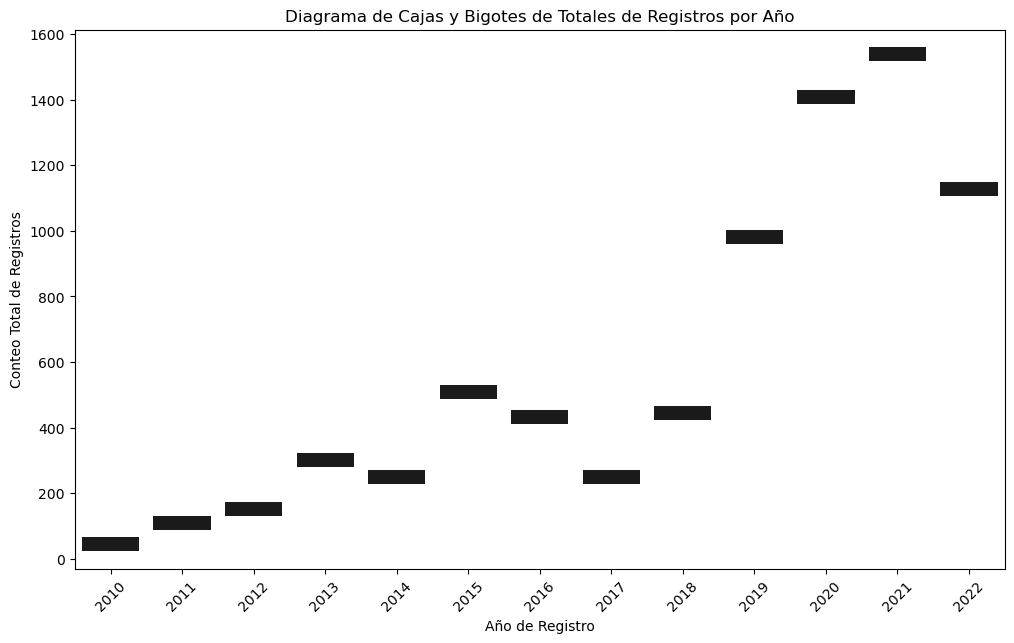

In [30]:
#Realizar Diagrama de cajas y bigotes  

data = {'ANIO_REGISTRO': [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        'cantidad_registros': [44, 108, 150, 300, 250, 508, 431, 248, 444, 980, 1408, 1539, 1127]}

df_agregado = pd.DataFrame(data)

# Crear el diagrama de bigotes con líneas más gruesas
plt.figure(figsize=(12, 7))
sns.boxplot(x ='ANIO_REGISTRO',
            y ='cantidad_registros',
            data = df_agregado,
            hue ='ANIO_REGISTRO',
            legend = False,
            palette ="viridis",
            linewidth = 10.0) # <--- Aumenta este valor para líneas más gruesas

plt.title("Diagrama de Cajas y Bigotes de Totales de Registros por Año")
plt.xlabel("Año de Registro")
plt.ylabel("Conteo Total de Registros")
plt.xticks(rotation=45)
plt.show()

Matriz de correlacion
               ANIO_REGISTRO  CANTIDAD 
ANIO_REGISTRO            1.0        NaN
CANTIDAD                 NaN        NaN
----------------------------------------------------------------------------------------


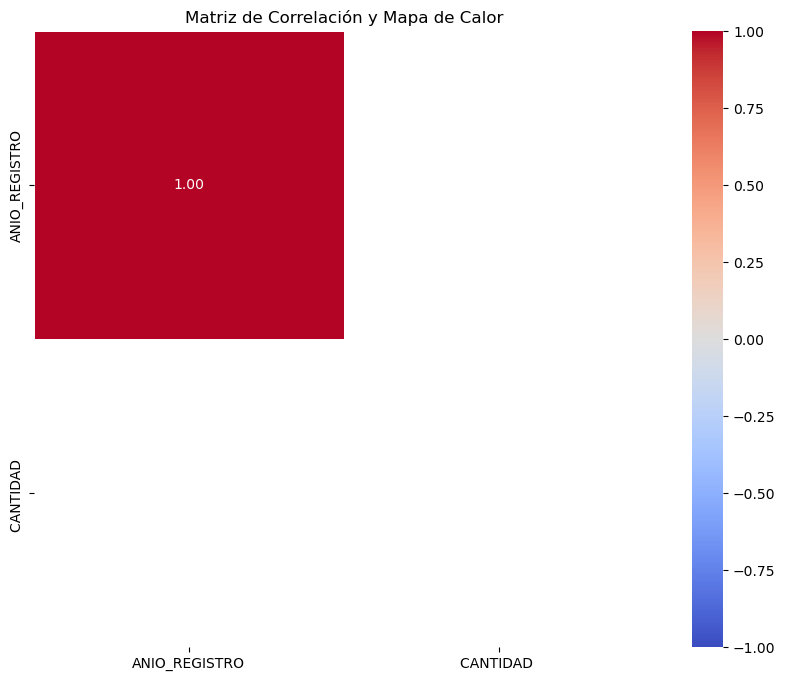

In [31]:
# matriz de correlacion y mapa de calor 
# El método .corr() calcula el coeficiente de correlación de Pearson por defecto.
matriz_correlacion = df.corr(numeric_only=True)
print("Matriz de correlacion")
print(matriz_correlacion)

print("----------------------------------------------------------------------------------------")

# 3. Crear el mapa de calor a partir de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion,
            annot = True,     # Muestra los valores de correlación en las celdas
            cmap = 'coolwarm', # Usa una paleta de colores divergente (azul/rojo)
            fmt = ".2f",      # Formato a 2 decimales
            linewidths = .5,  # Espacio entre celdas
            vmin = -1,        # Rango mínimo de correlación
            vmax = 1)          # Rango máximo de correlación
    
plt.title('Matriz de Correlación y Mapa de Calor')
plt.show()

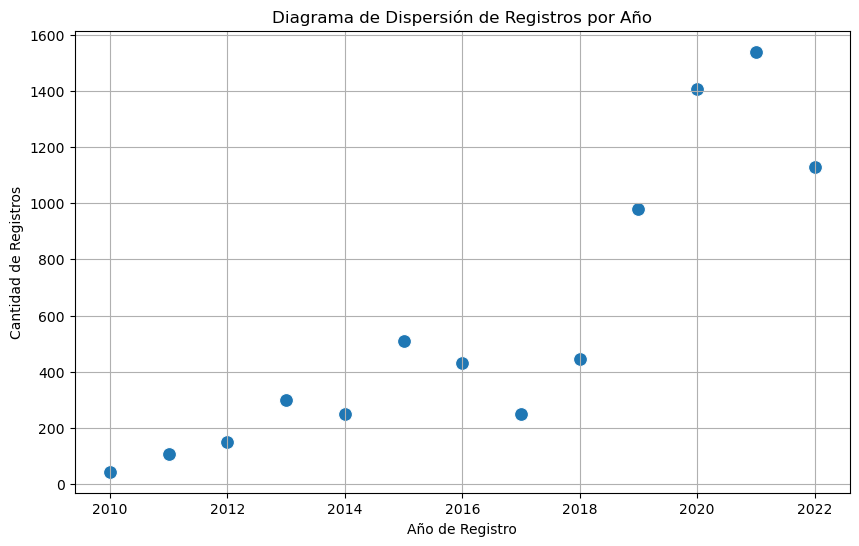

In [32]:
# Graficar matriz de correlacion y diagrama de  dispersion 
data = {
    'ANIO_REGISTRO': [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'cant': [44, 108, 150, 300, 250, 508, 431, 248, 444, 980, 1408, 1539, 1127]
}
df_agregado = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data = df_agregado, 
                x = 'ANIO_REGISTRO',
                y = 'cant', 
                s = 100) # s=100 define el tamaño de los puntos
                
plt.title('Diagrama de Dispersión de Registros por Año')
plt.xlabel('Año de Registro')
plt.ylabel('Cantidad de Registros')
plt.grid(True)
plt.show()

In [33]:
df.columns

Index(['FECHA_REGISTRO', 'ANIO_REGISTRO', 'CLASE', 'DEPARTAMENTO',
       'CANTIDAD '],
      dtype='object')

In [34]:
registros = df["DEPARTAMENTO"].value_counts()
print(registros)

DEPARTAMENTO
Bogota D.C.                   3461
Antioquia                     2330
Cundinamarca                   703
Valle del Cauca                443
Santander                      214
Meta                            47
Risaralda                       44
Norte de Santander              38
Caldas                          38
Huila                           34
Atlantico                       32
Cordoba                         31
Bolivar                         29
Cauca                           24
Quindio                         10
Tolima                          10
Caqueta                          9
Boyaca                           7
Narino                           6
Choco                            6
Casanare                         6
Archipielago de San Andres       4
Magdalena                        3
Arauca                           3
Guainia                          2
Cesar                            2
Amazonas                         1
Name: count, dtype: int64


In [35]:
departamentos = df["DEPARTAMENTO"].value_counts().to_dict()
print(departamentos)

{'Bogota D.C.': 3461, 'Antioquia': 2330, 'Cundinamarca': 703, 'Valle del Cauca': 443, 'Santander': 214, 'Meta': 47, 'Risaralda': 44, 'Norte de Santander': 38, 'Caldas': 38, 'Huila': 34, 'Atlantico': 32, 'Cordoba': 31, 'Bolivar': 29, 'Cauca': 24, 'Quindio': 10, 'Tolima': 10, 'Caqueta': 9, 'Boyaca': 7, 'Narino': 6, 'Choco': 6, 'Casanare': 6, 'Archipielago de San Andres': 4, 'Magdalena': 3, 'Arauca': 3, 'Guainia': 2, 'Cesar': 2, 'Amazonas': 1}


In [36]:
serie_datos = pd.Series(departamentos)
serie_datos = serie_datos.sort_values(ascending = False)
departamentos = serie_datos.index
registros = serie_datos.values

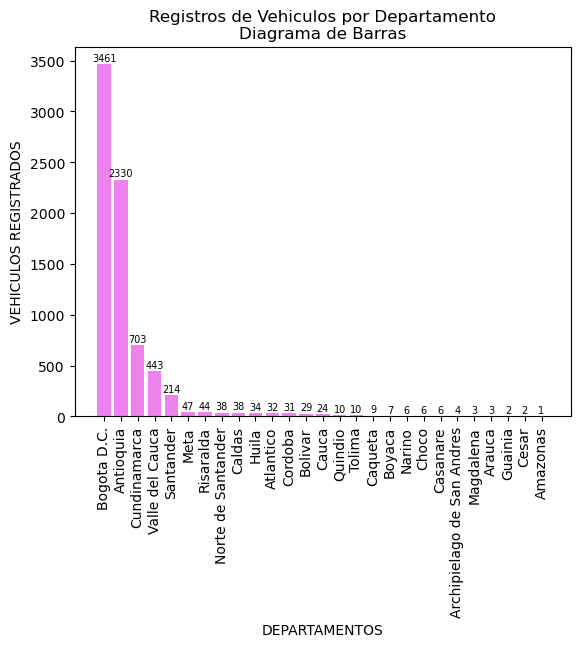

In [37]:
plt.bar(departamentos, registros,
       color = "violet")

# Añadir titulos y etiquetas
plt.title("Registros de Vehiculos por Departamento\nDiagrama de Barras")
plt.xlabel("DEPARTAMENTOS")
plt.ylabel("VEHICULOS REGISTRADOS")

threshold = 0

for i, v in enumerate(registros):
    if v > threshold:
        plt.text(i, v + 30, str(v),
            ha = "center",
            fontsize = 7,
            fontweight = "normal",
            color = "black")

# Rotar las etiquetas del eje X para mejor visualización si hay muchas
plt.xticks(rotation = 90, ha = 'center')

# Mostrar el gráfico
plt.show()

In [38]:
df["DEPARTAMENTO"] = df["DEPARTAMENTO"].str.replace(
    "Archipielago de San Andres", # Valor a buscar (exacto)
    "San Andres"                 # Valor nuevo y más corto
)

In [39]:
departamentos = df["DEPARTAMENTO"].value_counts()
print(departamentos)

DEPARTAMENTO
Bogota D.C.           3461
Antioquia             2330
Cundinamarca           703
Valle del Cauca        443
Santander              214
Meta                    47
Risaralda               44
Norte de Santander      38
Caldas                  38
Huila                   34
Atlantico               32
Cordoba                 31
Bolivar                 29
Cauca                   24
Quindio                 10
Tolima                  10
Caqueta                  9
Boyaca                   7
Narino                   6
Choco                    6
Casanare                 6
San Andres               4
Magdalena                3
Arauca                   3
Guainia                  2
Cesar                    2
Amazonas                 1
Name: count, dtype: int64


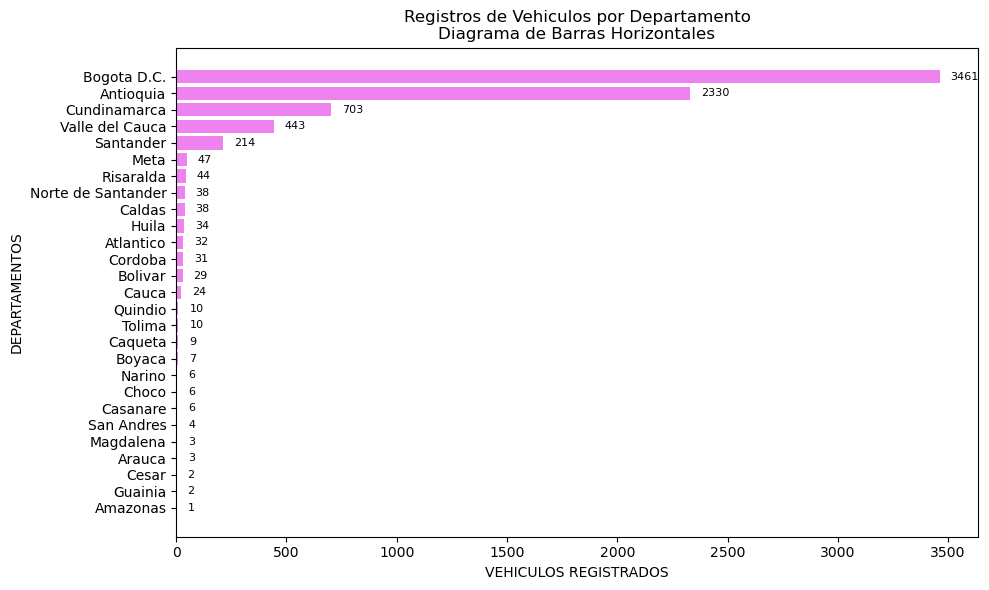

In [40]:
# plt.barh(departamentos, registros,
#         color = "violet")

# plt.title("Registros de Vehiculos por Departamento\nDiagrama de Barras Horizontales")
# plt.xlabel("DEPARTAMENTOS")
# plt.ylabel("VEHICULOS REGISTRADOS")

# for i, v in enumerate(registros):
#     plt.text(x = v + 10, y = i, s = str(v),
#             ha = "left",
#             va = "center",
#             fontsize = 8,
#             color = "black")

# # Ajustar diseño para evitar superposiciones de las etiquetas Y
# plt.tight_layout()

# plt.show()


conteo_deptos = df['DEPARTAMENTO'].value_counts()

# Ordenamos ascendente para que el más grande quede ARRIBA en la gráfica
conteo_deptos = conteo_deptos.sort_values(ascending=True)

# Extraemos las listas para matplotlib
departamentos = conteo_deptos.index.tolist()
registros = conteo_deptos.values.tolist()

plt.figure(figsize=(10, 6)) # Hacemos el lienzo un poco más grande

plt.barh(departamentos, registros, color="violet")

plt.title("Registros de Vehiculos por Departamento\nDiagrama de Barras Horizontales")

# CORRECCIÓN DE ETIQUETAS: 
# En barh, el eje X es la cantidad y el Y son los nombres
plt.xlabel("VEHICULOS REGISTRADOS") 
plt.ylabel("DEPARTAMENTOS")

# Ciclo para poner los textos
for i, v in enumerate(registros):
    # Aumenté el +10 a +50 para separar un poco más el texto de la barra
    plt.text(x = v + 50, y = i, s = str(v),
             ha = "left",
             va = "center",
             fontsize = 8,
             color = "black")

plt.tight_layout()
plt.show()

In [41]:
conteo_vehiculos = df["CLASE"].value_counts()
print(conteo_vehiculos)

tipos_vehiculos = conteo_vehiculos.index
print(tipos_vehiculos)

CLASE
AUTOMOVIL       2339
MOTOCICLETA     1397
BUS             1175
CAMIONETA       1017
CUADRICICLO      905
CAMION           331
MOTOCARRO        215
TRICIMOTO        132
MOTOTRICICLO      16
MICROBUS           6
CUATRIMOTO         3
TRACTOCAMION       1
Name: count, dtype: int64
Index(['AUTOMOVIL', 'MOTOCICLETA', 'BUS', 'CAMIONETA', 'CUADRICICLO', 'CAMION',
       'MOTOCARRO', 'TRICIMOTO', 'MOTOTRICICLO', 'MICROBUS', 'CUATRIMOTO',
       'TRACTOCAMION'],
      dtype='object', name='CLASE')


In [42]:
tipos_vehiculos = df["CLASE"]
print(tipos_vehiculos)

0       MOTOCICLETA
1         CAMIONETA
2         AUTOMOVIL
3         AUTOMOVIL
4         CAMIONETA
           ...     
7532    CUADRICICLO
7533    CUADRICICLO
7534    CUADRICICLO
7535    CUADRICICLO
7536    CUADRICICLO
Name: CLASE, Length: 7537, dtype: object


In [43]:
# Calcular la moda de los registros por año
# Agrupamos por 'ANIO_REGISTRO' y contamos cualquier otra columna CANTIDAD
conteo_por_anio = df.groupby('ANIO_REGISTRO')['CANTIDAD '].count()

#print("Conteo de registros por año\n")
#print(conteo_por_anio)

moda_conteo = conteo_por_anio.mode()

print("La(s) moda(s) de los conteos por año es/son:")
print(moda_conteo)

La(s) moda(s) de los conteos por año es/son:
0       44
1      108
2      150
3      248
4      250
5      300
6      431
7      444
8      508
9      980
10    1127
11    1408
12    1539
Name: CANTIDAD , dtype: int64


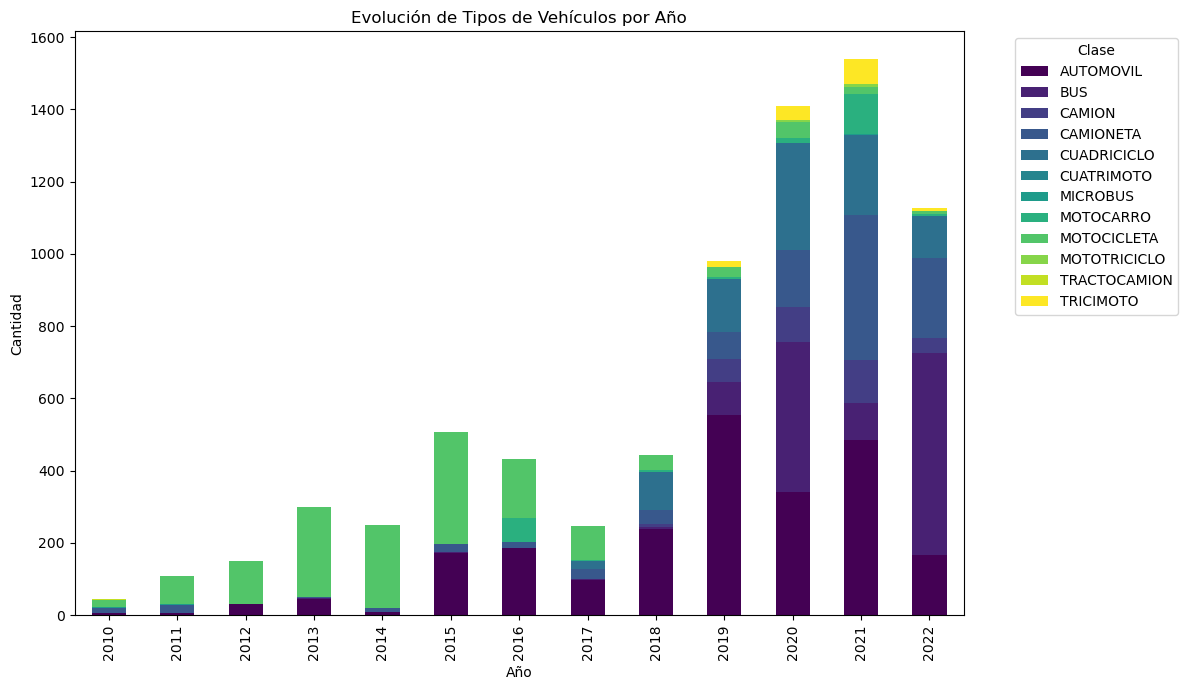

In [44]:
# Crear una tabla cruzada: Años en filas, Clases en columnas
tabla_cruzada = pd.crosstab(df['ANIO_REGISTRO'], df['CLASE'])

# Graficar como barras apiladas
tabla_cruzada.plot(kind='bar', 
                    stacked=True, 
                    figsize=(12, 7), 
                    colormap='viridis')

plt.title('Evolución de Tipos de Vehículos por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend(title='Clase', 
            bbox_to_anchor=(1.05, 1), 
            loc='upper left')
plt.tight_layout()
plt.show()

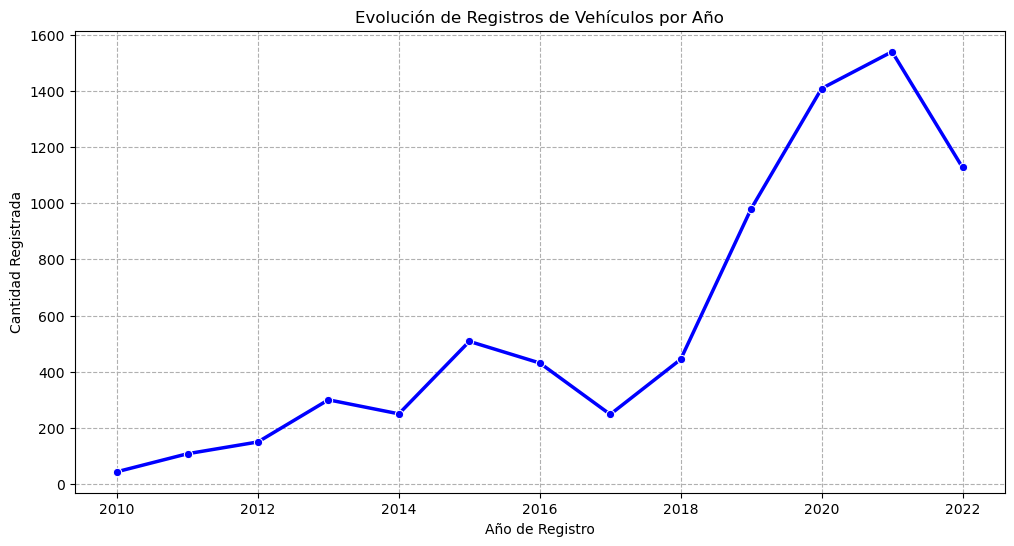

In [45]:
# Agrupar por año y contar filas
crecimiento_anual = df['ANIO_REGISTRO'].value_counts().sort_index().reset_index()
crecimiento_anual.columns = ['Año', 'Total']

plt.figure(figsize=(12, 6))
sns.lineplot(data = crecimiento_anual, 
            x = 'Año', 
            y = 'Total', 
            marker = 'o', 
            linewidth = 2.5, 
            color = 'blue')

plt.title('Evolución de Registros de Vehículos por Año')
plt.xlabel('Año de Registro')
plt.ylabel('Cantidad Registrada')
plt.grid(True, linestyle='--')
plt.show()

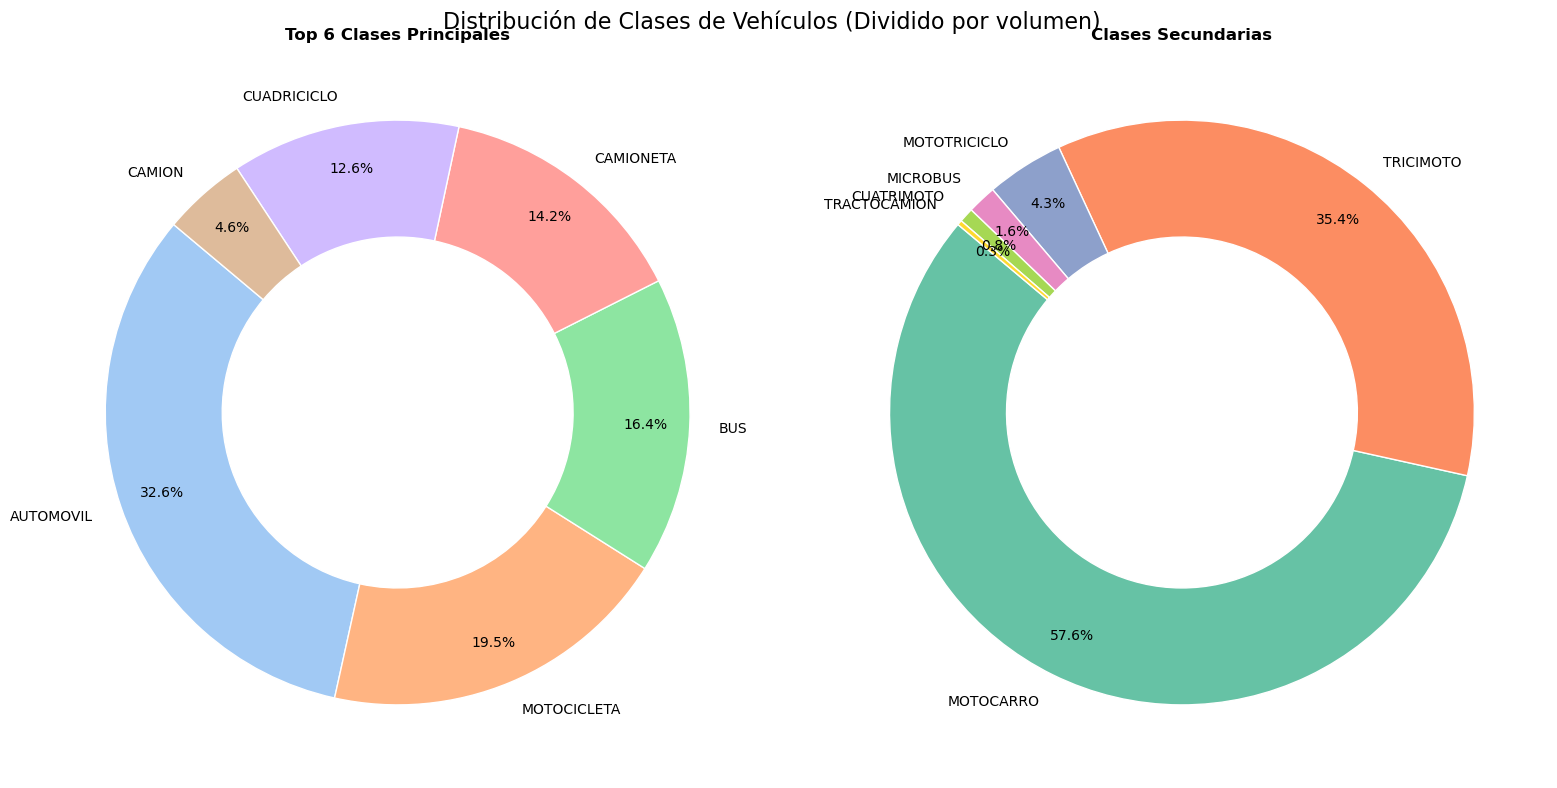

In [46]:
conteo_clase = df['CLASE'].value_counts()

# 2. Dividimos los datos en dos grupos
# Grupo 1: Los 6 más grandes (índices 0 a 6)
grupo_principal = conteo_clase.iloc[:6]

# Grupo 2: Los siguientes (índices 6 en adelante)
# Nota: Si tienes muchísimas categorías, esto tomará todas las restantes.
# Si solo quieres las "siguientes 6", podrías usar conteo_clase.iloc[6:12]
grupo_secundario = conteo_clase.iloc[6:]

# 3. Configuración de la figura con subplots (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Distribución de Clases de Vehículos (Dividido por volumen)', fontsize=16)

# --- GRÁFICO 1: Los Principales ---
colores_1 = sns.color_palette('pastel')[0:6]
ax[0].pie(grupo_principal, 
          labels=grupo_principal.index, 
          autopct='%1.1f%%', 
          startangle=140, 
          colors=colores_1,
          pctdistance=0.85,  # Mueve el porcentaje hacia afuera para efecto dona
          wedgeprops=dict(width=0.4, edgecolor='w')) # width crea el agujero (Dona)

ax[0].set_title('Top 6 Clases Principales', fontsize=12, weight='bold')

# --- GRÁFICO 2: Los Secundarios ---
# Usamos una paleta diferente para diferenciar visualmente
colores_2 = sns.color_palette('Set2')[0:len(grupo_secundario)]

# Verificamos si el grupo secundario tiene datos para evitar errores
if not grupo_secundario.empty:
    ax[1].pie(grupo_secundario, 
              labels=grupo_secundario.index, 
              autopct='%1.1f%%', 
              startangle=140, 
              colors=colores_2,
              pctdistance=0.85,
              wedgeprops=dict(width=0.4, edgecolor='w'))
    
    ax[1].set_title('Clases Secundarias', fontsize=12, weight='bold')
else:
    ax[1].text(0.5, 0.5, 'No hay suficientes datos para un segundo gráfico', 
               ha='center', va='center')

# Ajuste final
plt.tight_layout()
plt.show()

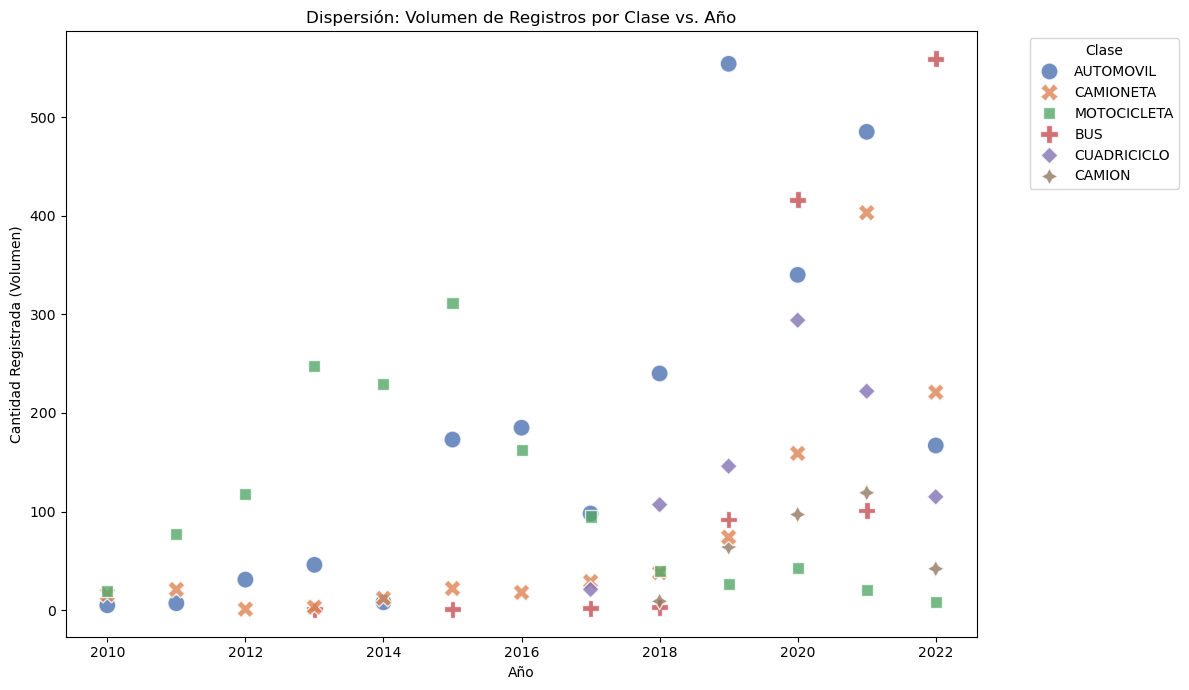

In [47]:
scatter_data = df.groupby(['ANIO_REGISTRO', 'CLASE']).size().reset_index(name='CONTEO_REAL')

# (Opcional) Filtramos solo las clases principales para que el gráfico sea legible
top_clases = df['CLASE'].value_counts().nlargest(6).index
scatter_data = scatter_data[scatter_data['CLASE'].isin(top_clases)]

plt.figure(figsize=(12, 7))

# Paso B: Graficar
sns.scatterplot(
    data=scatter_data, 
    x='ANIO_REGISTRO', 
    y='CONTEO_REAL', 
    hue='CLASE',     # Diferente color para cada clase
    style='CLASE',   # Diferente forma de punto para cada clase (opcional)
    s=150,           # Tamaño de los puntos
    alpha=0.8,       # Transparencia
    palette='deep'
)

plt.title('Dispersión: Volumen de Registros por Clase vs. Año')
plt.xlabel('Año')
plt.ylabel('Cantidad Registrada (Volumen)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clase')
plt.tight_layout()
plt.show()

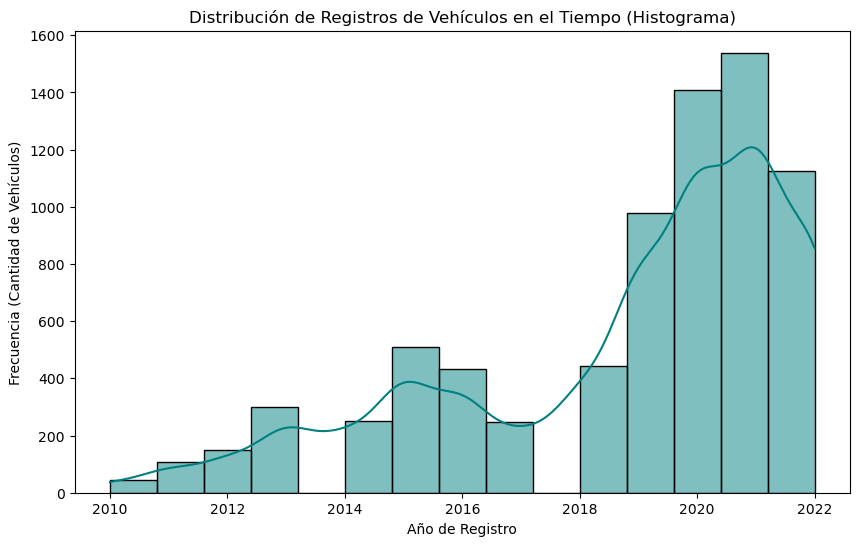

In [48]:
plt.figure(figsize=(10, 6))

# kde=True añade la línea curva de densidad suave sobre las barras
sns.histplot(data=df, x='ANIO_REGISTRO', bins=15, kde=True, color='teal')

plt.title('Distribución de Registros de Vehículos en el Tiempo (Histograma)')
plt.xlabel('Año de Registro')
plt.ylabel('Frecuencia (Cantidad de Vehículos)')
plt.show()

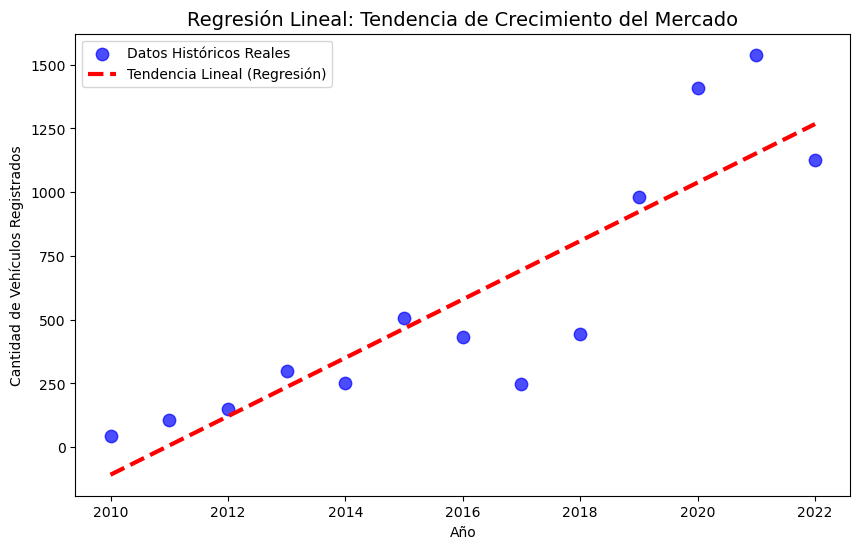

In [49]:
df_reg = df['ANIO_REGISTRO'].value_counts().reset_index()
df_reg.columns = ['ANIO', 'TOTAL']

# Limpieza: Ordenamos por año y filtramos errores (ej. año 0 o nulos)
df_reg = df_reg[df_reg['ANIO'] > 2000].sort_values('ANIO')

# B. Modelo de Regresión
X = df_reg[['ANIO']]  # Variable Independiente (Debe ser 2D)
y = df_reg['TOTAL']   # Variable Dependiente

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)  # Predicciones (La línea roja)

# C. Graficar
plt.figure(figsize=(10, 6))

# Puntos reales (Scatter)
plt.scatter(X, y, color='blue', label='Datos Históricos Reales', s=80, alpha=0.7)

# Línea de tendencia (Regresión)
plt.plot(X, y_pred, color='red', linewidth=3, linestyle='--', label='Tendencia Lineal (Regresión)')

plt.title('Regresión Lineal: Tendencia de Crecimiento del Mercado', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de Vehículos Registrados')
plt.legend()
plt.show()

In [51]:
df.to_excel('data_clean.xlsx', index=False)